<a href="https://colab.research.google.com/github/mp1605/CS-4410-Intro-to-Machine-Learning-/blob/main/Homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 5



In [1]:
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_iris, fetch_openml
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

# The same thread limit applies to both models for a consistent comparison.
thread_limit = threadpool_limits(limits=2)
print('Python:', sys.version.split()[0])
print('scikit-learn:', sklearn.__version__)

Python: 3.13.15
scikit-learn: 1.6.1


In [2]:
iris = load_iris()
X_iris = iris.data
print('Iris features:', X_iris.shape)
# Use all four original features to match the supplied WCSS scale.
# Target labels are not used to fit clusters or choose the elbow.
ks = range(1, 11)
wcss = []
for k in ks:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=11)
    kmeans.fit(X_iris)
    wcss.append(kmeans.inertia_)
print(pd.DataFrame({'k': list(ks), 'WCSS': wcss}).to_string(index=False))

Iris features: (150, 4)
 k       WCSS
 1 681.370600
 2 152.347952
 3  78.851441
 4  57.228473
 5  46.446182
 6  39.066035
 7  34.298230
 8  30.063111
 9  28.024977
10  26.393242


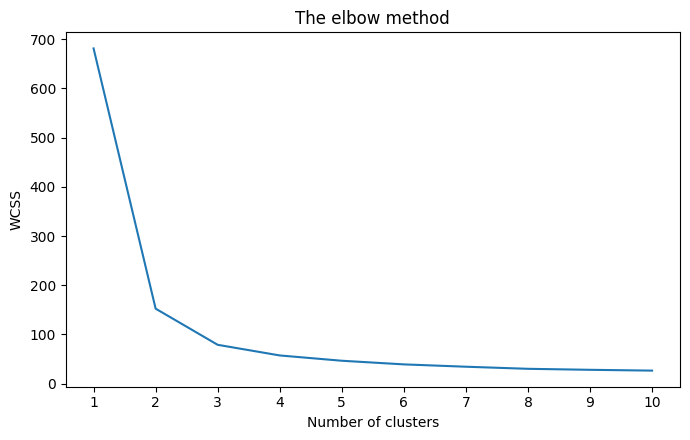

In [3]:
plt.figure(figsize=(7, 4.5))
plt.plot(list(ks), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(list(ks))
plt.tight_layout()
plt.show()

### Part 1 answer
**A reasonable visual elbow is k = 3.** WCSS drops sharply from k = 1 to 2, decreases further to 3, and then improves more slowly. This agrees with the three known Iris species. The elbow is a visual heuristic: k = 2 is also a prominent bend, so the plot does not mathematically prove a unique optimal k. Matching the number of species does not mean every sample is clustered correctly. The labels are used only to check the known class count after interpreting the curve.

## Part 2 — MNIST logistic regression before and after PCA


In [4]:
start = time.perf_counter()
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = np.asarray(mnist.data, dtype=np.float64)
y = np.asarray(mnist.target, dtype=np.int64)
print('Download/load time (excluded from comparison):', round(time.perf_counter() - start, 2), 'seconds')
print('Feature matrix:', X.shape)
print('Target array:', y.shape)
print('Classes:', np.unique(y))
assert X.shape == (70000, 784)
assert y.shape == (70000,)
# Release the dataset wrapper; X and y retain the data needed below.
del mnist

Download/load time (excluded from comparison): 29.02 seconds
Feature matrix: (70000, 784)
Target array: (70000,)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=11, stratify=y)
del X, y
print('Training:', X_train.shape, y_train.shape)
print('Testing:', X_test.shape, y_test.shape)

Training: (56000, 784) (56000,)
Testing: (14000, 784) (14000,)


In [6]:
start = time.perf_counter()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
scaling_seconds = time.perf_counter() - start
del X_train, X_test
print(f'Scaling training and testing data: {scaling_seconds:.3f} seconds')

Scaling training and testing data: 0.734 seconds


In [7]:
def fit_and_score(model, train_features, test_features):
    start = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', ConvergenceWarning)
        model.fit(train_features, y_train)
    fit_seconds = time.perf_counter() - start
    converged = not any(issubclass(w.category, ConvergenceWarning) for w in caught)
    for w in caught:
        print(f'{w.category.__name__}: {w.message}')
    start = time.perf_counter()
    accuracy = model.score(test_features, y_test)
    score_seconds = time.perf_counter() - start
    print(f'Fit time: {fit_seconds:.3f} seconds')
    print(f'Test accuracy: {accuracy:.4%}')
    print('Iterations:', model.n_iter_, '| Converged:', converged)
    return fit_seconds, score_seconds, accuracy, converged

logisticRegr = LogisticRegression(solver='lbfgs', max_iter=2000)
fit_without, score_without, accuracy_without, converged_without = fit_and_score(
    logisticRegr, X_train_scaled, X_test_scaled)

Fit time: 95.011 seconds
Test accuracy: 91.3286%
Iterations: [179] | Converged: True


In [8]:
start = time.perf_counter()
pca = PCA(0.95, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
pca_seconds = time.perf_counter() - start
print('Original feature count:', X_train_scaled.shape[1])
print('PCA component count:', pca.n_components_)
print(f'Variance retained: {pca.explained_variance_ratio_.sum():.4%}')
print(f'PCA fit and transformations: {pca_seconds:.3f} seconds')
print('Reduced train/test shapes:', X_train_pca.shape, X_test_pca.shape)

Original feature count: 784
PCA component count: 331
Variance retained: 95.0283%
PCA fit and transformations: 16.343 seconds
Reduced train/test shapes: (56000, 331) (14000, 331)


In [9]:
logisticRegr_pca = LogisticRegression(solver='lbfgs', max_iter=2000)
fit_with, score_with, accuracy_with, converged_with = fit_and_score(
    logisticRegr_pca, X_train_pca, X_test_pca)

Fit time: 69.304 seconds
Test accuracy: 92.2143%
Iterations: [274] | Converged: True


In [10]:
total_without = scaling_seconds + fit_without + score_without
total_with = scaling_seconds + pca_seconds + fit_with + score_with
results = pd.DataFrame({
    'Method': ['Without PCA', 'With PCA (95%)'],
    'Features': [X_train_scaled.shape[1], pca.n_components_],
    'Scaling (s)': [scaling_seconds, scaling_seconds],
    'PCA (s)': [0.0, pca_seconds],
    'LR fit (s)': [fit_without, fit_with],
    'Test scoring (s)': [score_without, score_with],
    'Total (s)': [total_without, total_with],
    'Accuracy (%)': [accuracy_without * 100, accuracy_with * 100],
    'Converged': [converged_without, converged_with]
})
print(results.round(4).to_string(index=False))
print(f'LR fit time saved: {fit_without - fit_with:.3f} seconds')
print(f'LR fit speedup (without / with): {fit_without / fit_with:.2f}x')
print(f'Total time saved: {total_without - total_with:.3f} seconds')
print(f'Total speedup (without / with): {total_without / total_with:.2f}x')
print(f'Accuracy change (with minus without): {(accuracy_with - accuracy_without) * 100:+.3f} percentage points')

        Method  Features  Scaling (s)  PCA (s)  LR fit (s)  Test scoring (s)  Total (s)  Accuracy (%)  Converged
   Without PCA       784       0.7336   0.0000     95.0110            0.0625    95.8071       91.3286       True
With PCA (95%)       331       0.7336  16.3434     69.3037            0.0196    86.4002       92.2143       True
LR fit time saved: 25.707 seconds
LR fit speedup (without / with): 1.37x
Total time saved: 9.407 seconds
Total speedup (without / with): 1.11x
Accuracy change (with minus without): +0.886 percentage points


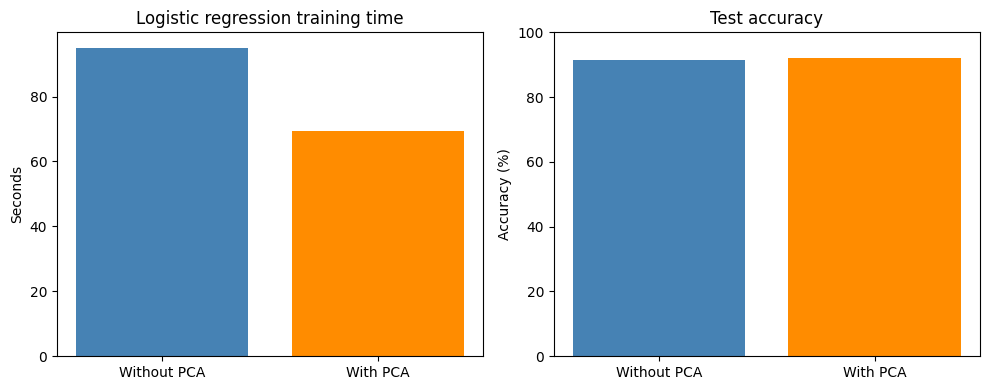

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ['Without PCA', 'With PCA']
axes[0].bar(labels, [fit_without, fit_with], color=['steelblue', 'darkorange'])
axes[0].set_title('Logistic regression training time')
axes[0].set_ylabel('Seconds')
axes[1].bar(labels, [accuracy_without * 100, accuracy_with * 100], color=['steelblue', 'darkorange'])
axes[1].set_title('Test accuracy')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()

In [12]:
print(f'PCA reduced 784 features to {pca.n_components_} components, retaining '
      f'{pca.explained_variance_ratio_.sum():.2%} of training variance.')
if fit_with < fit_without:
    print(f'PCA made logistic regression fitting {fit_without / fit_with:.2f} times faster in this run.')
else:
    print('PCA did not speed up logistic regression fitting in this run.')
if total_with < total_without:
    print(f'Including preprocessing and scoring, the PCA workflow was {total_without / total_with:.2f} times faster.')
else:
    print('Including preprocessing and scoring, the PCA workflow was not faster in this run.')
print(f'Test accuracy was {accuracy_without:.2%} without PCA and {accuracy_with:.2%} with PCA.')
if not (converged_without and converged_with):
    print('At least one model did not converge. Increase max_iter equally for both and rerun before drawing conclusions.')

PCA reduced 784 features to 331 components, retaining 95.03% of training variance.
PCA made logistic regression fitting 1.37 times faster in this run.
Including preprocessing and scoring, the PCA workflow was 1.11 times faster.
Test accuracy was 91.33% without PCA and 92.21% with PCA.
